<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/example_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

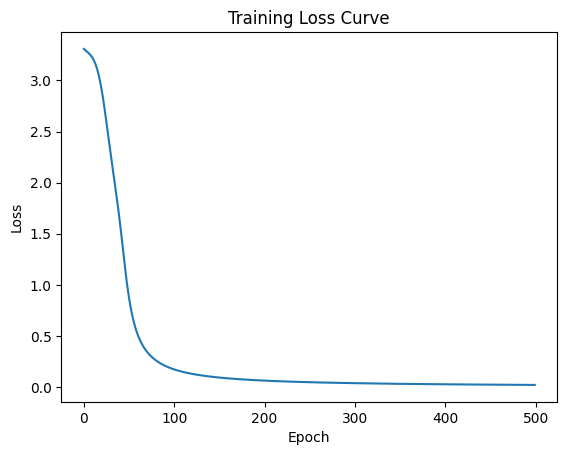


Final Predictions:
[[0.  ]
 [0.99]
 [0.01]]
[[0.  ]
 [0.  ]
 [0.99]]
[[0.99]
 [0.  ]
 [0.01]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Functions --------
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def loss_fn(y, p):
    return -np.sum(y * np.log(p + 1e-12))

# -------- Initialize Weights --------
Wxh = np.random.randn(2,3)*0.1
Whh = np.random.randn(2,2)*0.1
Why = np.random.randn(3,2)*0.1
bh = np.zeros((2,1))
by = np.zeros((3,1))

# -------- Data (abc -> bca) --------
x = [np.eye(3)[:,i:i+1] for i in range(3)]
t = [np.eye(3)[:,(i+1)%3:(i+1)%3+1] for i in range(3)]

lr = 0.1
loss_history = []

# -------- Training --------
for epoch in range(500):

    h = [np.zeros((2,1))]
    p = []
    loss = 0

    # Forward
    for i in range(3):
        h.append(np.tanh(Wxh@x[i] + Whh@h[i] + bh))
        y = Why@h[i+1] + by
        p.append(softmax(y))
        loss += loss_fn(t[i], p[i])

    loss_history.append(loss)

    # Backward
    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dWhy = np.zeros_like(Why)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)
    dh_next = np.zeros((2,1))

    for i in reversed(range(3)):
        dy = p[i] - t[i]
        dWhy += dy @ h[i+1].T
        dby += dy
        dh = Why.T @ dy + dh_next
        dh_raw = (1 - h[i+1]**2) * dh
        dbh += dh_raw
        dWxh += dh_raw @ x[i].T
        dWhh += dh_raw @ h[i].T
        dh_next = Whh.T @ dh_raw

    # Update
    Wxh -= lr*dWxh
    Whh -= lr*dWhh
    Why -= lr*dWhy
    bh  -= lr*dbh
    by  -= lr*dby

# -------- Plot Loss Curve --------
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# -------- Final Predictions --------
print("\nFinal Predictions:")
for i in range(3):
    print(np.round(p[i],2))

Epoch: 0 Loss: 3.2948169056332213
Epoch: 100 Loss: 3.1334270073039296
Epoch: 200 Loss: 0.5840978900292383
Epoch: 300 Loss: 0.14268822194979675
Epoch: 400 Loss: 0.07650819099454786


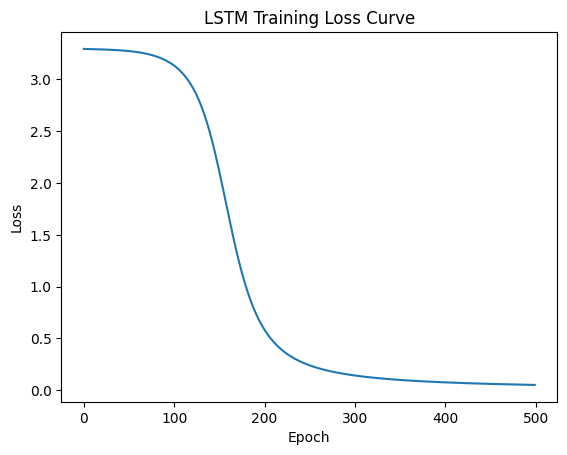


Final Predictions:
[[0.  ]
 [0.98]
 [0.01]]
[[0.01]
 [0.01]
 [0.98]]
[[0.99]
 [0.  ]
 [0.01]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Functions ----------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def loss_fn(y, p):
    return -np.sum(y * np.log(p + 1e-12))

# ---------- Sizes ----------
input_size = 3
hidden_size = 2
output_size = 3

# ---------- Initialize Weights ----------
def init_gate():
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1

Wf, Wi, Wo, Wc = init_gate(), init_gate(), init_gate(), init_gate()
bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bc = np.zeros((hidden_size,1))
Why = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size,1))

# ---------- Data (abc -> bca) ----------
x = [np.eye(3)[:,i:i+1] for i in range(3)]
t = [np.eye(3)[:,(i+1)%3:(i+1)%3+1] for i in range(3)]

lr = 0.1
loss_history = []

# ---------- Training ----------
for epoch in range(500):

    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))

    hs, cs, zs = [h], [c], []
    fs, ins, os, cts, ps = [], [], [], [], []
    loss = 0

    # ---- Forward ----
    for i in range(3):
        z = np.vstack((h, x[i]))
        f = sigmoid(Wf@z + bf)
        ii = sigmoid(Wi@z + bi)
        o = sigmoid(Wo@z + bo)
        ct = np.tanh(Wc@z + bc)

        c = f*c + ii*ct
        h = o*np.tanh(c)

        y = Why@h + by
        p = softmax(y)

        zs.append(z); fs.append(f); ins.append(ii)
        os.append(o); cts.append(ct)
        hs.append(h); cs.append(c)
        ps.append(p)

        loss += loss_fn(t[i], p)

    loss_history.append(loss)

    # ---- Backward ----
    dWf=dWi=dWo=dWc=0
    dWf=np.zeros_like(Wf); dWi=np.zeros_like(Wi)
    dWo=np.zeros_like(Wo); dWc=np.zeros_like(Wc)
    dbf=np.zeros_like(bf); dbi=np.zeros_like(bi)
    dbo=np.zeros_like(bo); dbc=np.zeros_like(bc)
    dWhy=np.zeros_like(Why); dby=np.zeros_like(by)

    dh_next = np.zeros((hidden_size,1))
    dc_next = np.zeros((hidden_size,1))

    for i in reversed(range(3)):
        dy = ps[i] - t[i]
        dWhy += dy @ hs[i+1].T
        dby += dy

        dh = Why.T @ dy + dh_next
        dc = dh*os[i]*(1-np.tanh(cs[i+1])**2) + dc_next

        do = dh*np.tanh(cs[i+1])
        do_raw = do*os[i]*(1-os[i])

        df = dc*cs[i]
        df_raw = df*fs[i]*(1-fs[i])

        di = dc*cts[i]
        di_raw = di*ins[i]*(1-ins[i])

        dct = dc*ins[i]
        dct_raw = dct*(1-cts[i]**2)

        dWf += df_raw @ zs[i].T
        dWi += di_raw @ zs[i].T
        dWo += do_raw @ zs[i].T
        dWc += dct_raw @ zs[i].T

        dbf += df_raw; dbi += di_raw
        dbo += do_raw; dbc += dct_raw

        dz = (Wf.T@df_raw + Wi.T@di_raw +
              Wo.T@do_raw + Wc.T@dct_raw)

        dh_next = dz[:hidden_size,:]
        dc_next = dc*fs[i]

    # ---- Update ----
    for param, dparam in zip(
        [Wf,Wi,Wo,Wc,Why,bf,bi,bo,bc,by],
        [dWf,dWi,dWo,dWc,dWhy,dbf,dbi,dbo,dbc,dby]):
        param -= lr*dparam

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)

# ---------- Plot Loss Curve ----------
plt.plot(loss_history)
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ---------- Final Predictions ----------
print("\nFinal Predictions:")
for i in range(3):
    print(np.round(ps[i],2))

In [ ]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)

# ---- Functions ----
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def cross_entropy(y, p):
    return -np.sum(y * np.log(p + 1e-12))

# ---- Fixed Weights ----
Wxh = np.array([[-1.753416, 0.9836007, 1.2459822],
                [-1.117427, 2.0291977, 0.5590203]])

Whh = np.array([[0.3323058, 1.704173],
                [-0.4059835, 1.069699]])

Why = np.array([[ 5.0668307, 1.239699],
                [-3.2882083,-2.307849],
                [-0.8786225, 2.268150]])

bh = np.array([[-0.0238333],[0.1707909]])
by = np.array([[0.03411441],[-0.21828305],[0.78416864]])

# ---- Inputs (abc) ----
x = [np.eye(3)[:,i:i+1] for i in range(3)]
t = [np.eye(3)[:,(i+1)%3:(i+1)%3+1] for i in range(3)]

# ---- Forward Pass ----
h = np.zeros((2,1))
loss = 0

print("Forward Pass Outputs:\n")

for i in range(3):
    h = np.tanh(Wxh@x[i] + Whh@h + bh)
    y = Why@h + by
    p = softmax(y)

    loss += cross_entropy(t[i], p)

    print(f"Step {i+1}")
    print("Hidden state h:")
    print(h)
    print("Prediction p:")
    print(np.round(p,2))
    print()

print("Total Loss:", round(loss,3))

Forward Pass Outputs:

Step 1
Hidden state h:
[[-0.944]
 [-0.738]]
Prediction p:
[[0.  ]
 [0.99]
 [0.01]]

Step 2
Hidden state h:
[[-0.546]
 [ 0.946]]
Prediction p:
[[0.01]
 [0.02]
 [0.98]]

Step 3
Hidden state h:
[[0.99 ]
 [0.961]]
Prediction p:
[[0.98]
 [0.  ]
 [0.02]]

Total Loss: 0.05


In [ ]:
import numpy as np

# Random weights
Wx = np.random.randn(2, 3)
Wh = np.random.randn(3, 3)
Wy = np.random.randn(3, 2)

h = np.zeros((1,3))  # initial hidden

x = np.array([[1, 0]])  # input

# Forward
h = np.tanh(x @ Wx + h @ Wh)
y = h @ Wy

print("Hidden:", h)
print("Output:", y)

Hidden: [[-0.53188507  0.4061912   0.6383121 ]]
Output: [[ 0.71602102 -0.70842291]]


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AvgPool2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load dataset
(x_train,y_train),(x_test,y_test) = mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1,28,28,1)/255
x_test  = x_test.reshape(-1,28,28,1)/255

# One-hot encoding
y_train = to_categorical(y_train,10)
y_test  = to_categorical(y_test,10)

# Model (LeNet-5)
model = Sequential([
    Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    AvgPool2D((2,2)),
    Conv2D(16,(5,5),activation='tanh'),
    AvgPool2D((2,2)),
    Flatten(),
    Dense(120,activation='tanh'),
    Dense(84,activation='tanh'),
    Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train for 20 epochs
model.fit(x_train,y_train,epochs=20,batch_size=128,
          validation_data=(x_test,y_test))

# Evaluate
loss,acc = model.evaluate(x_test,y_test)
print("Test Accuracy:",acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.8102 - loss: 0.6513 - val_accuracy: 0.9528 - val_loss: 0.1622
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9543 - loss: 0.1515 - val_accuracy: 0.9658 - val_loss: 0.1094
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9713 - loss: 0.0950 - val_accuracy: 0.9767 - val_loss: 0.0739
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9797 - loss: 0.0678 - val_accuracy: 0.9803 - val_loss: 0.0627
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9834 - loss: 0.0530 - val_accuracy: 0.9833 - val_loss: 0.0531
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9877 - loss: 0.0407 - val_accuracy: 0.9839 - val_loss: 0.0476
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9888 - loss: 0.0345 - val_accuracy: 0.9849 - val_loss: 0.0482
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9912 - loss: 0.0288 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load data
(x_train,y_train),(x_test,y_test) = mnist.load_data()

# Reshape + normalize
x_train = x_train.reshape(-1,28,28,1)/255
x_test  = x_test.reshape(-1,28,28,1)/255

# One-hot encoding
y_train = to_categorical(y_train,10)
y_test  = to_categorical(y_test,10)

# Model (AlexNet style)
model = Sequential([
    Conv2D(96,(5,5),strides=4,activation='relu',input_shape=(28,28,1)),
    MaxPool2D((2,2)),
    Conv2D(256,(3,3),padding='same',activation='relu'),
    MaxPool2D((2,2),strides=1),
    Conv2D(384,(1,1),activation='relu'),
    Conv2D(384,(1,1),activation='relu'),
    Conv2D(256,(1,1),activation='relu'),
    Flatten(),
    Dense(512,activation='relu'),
    Dense(512,activation='relu'),
    Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (20 epochs)
model.fit(x_train,y_train,epochs=20,batch_size=128,
          validation_data=(x_test,y_test))

# Test
loss,acc = model.evaluate(x_test,y_test)
print("Test Accuracy:",acc)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 183ms/step - accuracy: 0.7181 - loss: 0.7860 - val_accuracy: 0.9642 - val_loss: 0.1223
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 182ms/step - accuracy: 0.9634 - loss: 0.1169 - val_accuracy: 0.9658 - val_loss: 0.1039
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 182ms/step - accuracy: 0.9750 - loss: 0.0807 - val_accuracy: 0.9693 - val_loss: 0.0992
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.9826 - loss: 0.0567 - val_accuracy: 0.9739 - val_loss: 0.0883
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 182ms/step - accuracy: 0.9832 - loss: 0.0517 - val_accuracy: 0.9675 - val_loss: 0.1120
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 185ms/step - accuracy: 0.9871 - loss: 0.0407 - val_accuracy: 0.9759 - val_loss: 0.0786
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.9889 - loss: 0.0347 - val_accuracy: 0.9754 - val_loss: 0.0907
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.9883 - loss: 0